# TVSD Dataset Exploration
**Goal**: Compute RDMs per brain area (V1, V4, IT) from normalized MUA data and visualize representational structure across the visual hierarchy.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from datasets.tvsd import load_tvsd, load_category_labels, get_area_electrode_counts

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load data & basic checks

In [2]:
# Load data for both monkeys (all electrodes, no quality filter yet for inspection)
data = {}
for monkey in ['N', 'F']:
    train, test, meta = load_tvsd(monkey, quality_threshold=0.0)  # no filter
    data[monkey] = {'train': train, 'test': test, 'meta': meta}
    
    print(f"=== Monkey {monkey} ===")
    print(f"  train: {train.shape}, test: {test.shape}")
    print(f"  train range: [{train.min():.3f}, {train.max():.3f}], NaNs: {np.isnan(train).sum()}")
    print(f"  test  range: [{test.min():.3f}, {test.max():.3f}], NaNs: {np.isnan(test).sum()}")
    print()

=== Monkey N ===
  train: (22248, 998), test: (100, 998)
  train range: [-3.125, 12.761], NaNs: 0
  test  range: [-1.610, 3.120], NaNs: 0



=== Monkey F ===
  train: (22248, 1015), test: (100, 1015)
  train range: [-2.590, 70.995], NaNs: 0
  test  range: [-1.755, 3.371], NaNs: 0



In [3]:
# Electrode counts per area (before and after quality filtering)
for monkey in ['N', 'F']:
    print(f"=== Monkey {monkey} ===")
    for thresh in [0.0, 0.3]:
        counts = get_area_electrode_counts(monkey, quality_threshold=thresh)
        print(f"  threshold={thresh}: " + ", ".join(f"{a}: {c['quality']}/{c['total']}" for a, c in counts.items()))

=== Monkey N ===
  threshold=0.0: V1: 492/512, V4: 256/256, IT: 250/256
  threshold=0.3: V1: 436/512, V4: 246/256, IT: 174/256
=== Monkey F ===
  threshold=0.0: V1: 511/512, IT: 314/320, V4: 190/192
  threshold=0.3: V1: 453/512, IT: 230/320, V4: 138/192


## 2. Oracle & SNR distributions per area

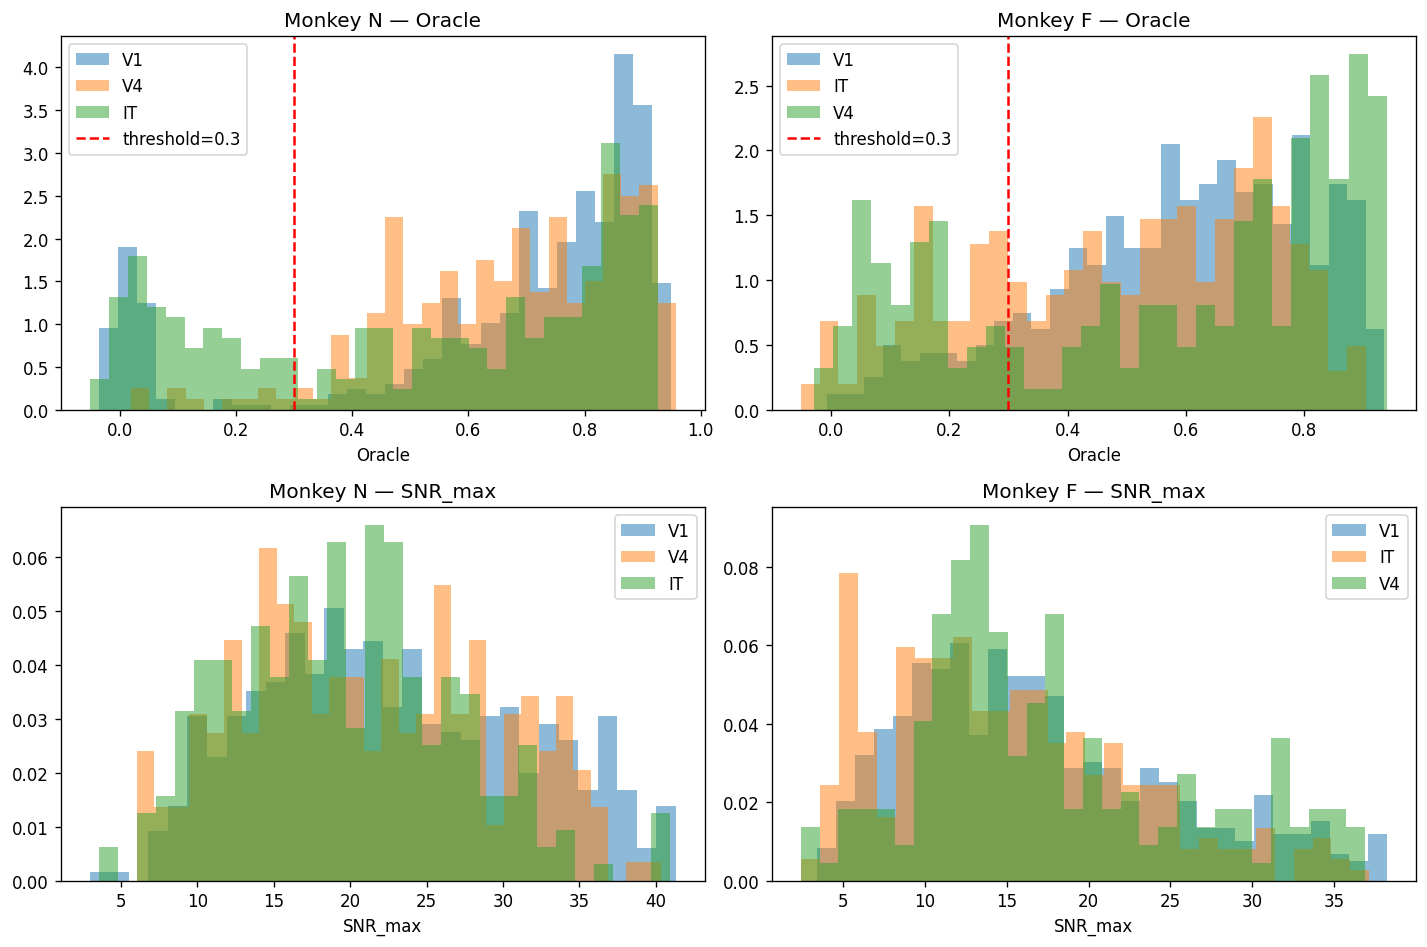

In [4]:
from datasets.tvsd import AREA_MAP

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, monkey in enumerate(['N', 'F']):
    meta = data[monkey]['meta']
    oracle = meta['oracle']
    snr_max = meta['snr_max']
    
    for row, (values, name) in enumerate([(oracle, 'Oracle'), (snr_max, 'SNR_max')]):
        ax = axes[row, col]
        for area, (start, end) in AREA_MAP[monkey].items():
            ax.hist(values[start:end], bins=30, alpha=0.5, label=area, density=True)
        if row == 0:
            ax.axvline(0.3, color='red', ls='--', label='threshold=0.3')
        ax.set_title(f'Monkey {monkey} — {name}')
        ax.legend()
        ax.set_xlabel(name)

plt.tight_layout()
plt.show()

## 3. Compute RDMs per area (correlation distance)

In [5]:
from rsatoolbox.data import Dataset
from rsatoolbox.rdm.calc import calc_rdm

def compute_neural_rdms(monkey, areas=['V1', 'V4', 'IT'], quality_threshold=0.3, method='correlation'):
    """Compute RDMs for each brain area from test_MUA data."""
    rdms = {}
    for area in areas:
        _, test_mua, meta = load_tvsd(monkey, area=area, quality_threshold=quality_threshold)
        ds = Dataset(test_mua, descriptors={'area': area})
        rdm = calc_rdm(ds, method=method)
        rdms[area] = rdm.get_matrices()[0]  # [100 × 100]
        print(f"Monkey {monkey} {area}: {meta['n_electrodes_selected']} electrodes, RDM shape {rdms[area].shape}")
    return rdms

rdms_N = compute_neural_rdms('N')
print()
rdms_F = compute_neural_rdms('F')

Monkey N V1: 436 electrodes, RDM shape (100, 100)


Monkey N V4: 246 electrodes, RDM shape (100, 100)


Monkey N IT: 174 electrodes, RDM shape (100, 100)



Monkey F V1: 453 electrodes, RDM shape (100, 100)


Monkey F V4: 138 electrodes, RDM shape (100, 100)


Monkey F IT: 230 electrodes, RDM shape (100, 100)


In [6]:
# Verify RDMs: symmetric, zero diagonal
for name, rdms in [('N', rdms_N), ('F', rdms_F)]:
    for area, rdm in rdms.items():
        is_sym = np.allclose(rdm, rdm.T, atol=1e-10)
        diag_zero = np.allclose(np.diag(rdm), 0, atol=1e-10)
        print(f"Monkey {name} {area}: symmetric={is_sym}, zero_diag={diag_zero}, range=[{rdm.min():.4f}, {rdm.max():.4f}]")

Monkey N V1: symmetric=True, zero_diag=True, range=[0.0000, 1.7134]
Monkey N V4: symmetric=True, zero_diag=True, range=[0.0000, 1.7685]
Monkey N IT: symmetric=True, zero_diag=True, range=[0.0000, 1.7289]
Monkey F V1: symmetric=True, zero_diag=True, range=[0.0000, 1.6990]
Monkey F V4: symmetric=True, zero_diag=True, range=[0.0000, 1.6625]
Monkey F IT: symmetric=True, zero_diag=True, range=[0.0000, 1.6442]


## 4. RDM heatmaps

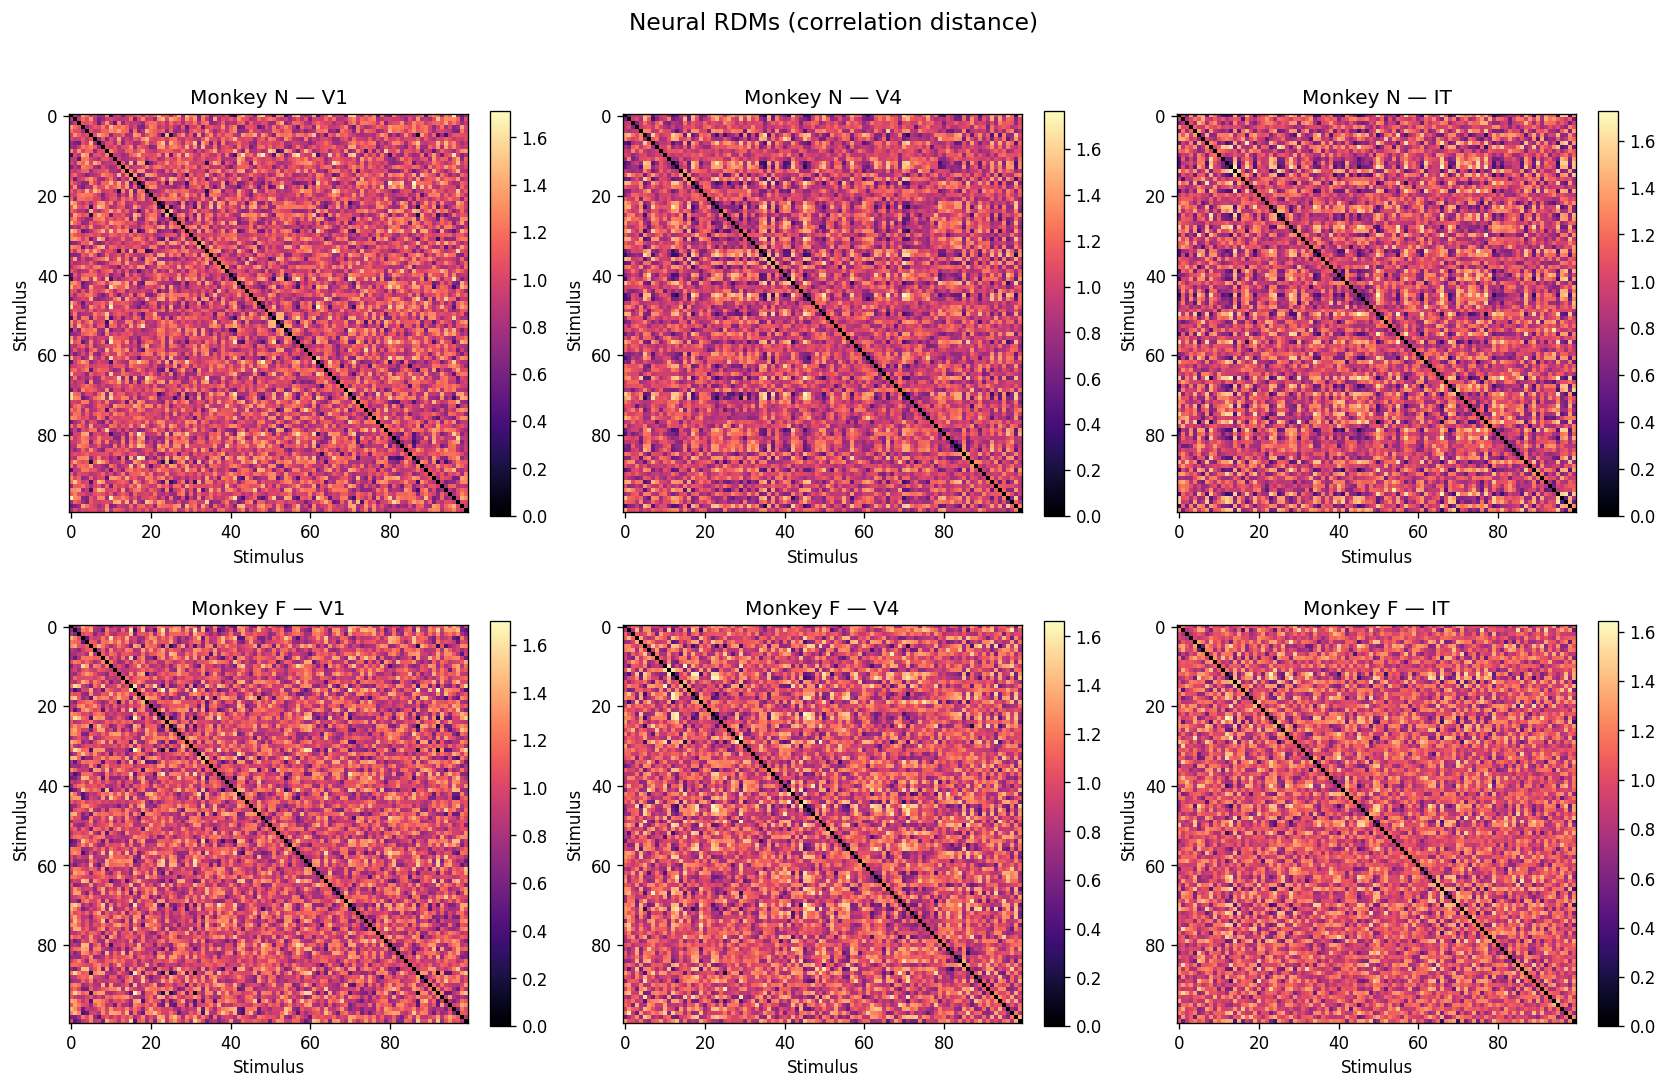

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
areas = ['V1', 'V4', 'IT']

for row, (monkey, rdms) in enumerate([('N', rdms_N), ('F', rdms_F)]):
    for col, area in enumerate(areas):
        ax = axes[row, col]
        rdm = rdms[area]
        im = ax.imshow(rdm, cmap='magma')
        ax.set_title(f'Monkey {monkey} — {area}')
        ax.set_xlabel('Stimulus')
        ax.set_ylabel('Stimulus')
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Neural RDMs (correlation distance)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. MDS visualization (colored by category)

In [8]:
# Load category labels for test stimuli
labels_N, _ = load_category_labels('N', 'test')
labels_F, _ = load_category_labels('F', 'test')

# Group into coarse categories (animate vs inanimate) for coloring
# Simple heuristic: label animate objects
animate_keywords = {
    'alligator', 'ant', 'bat', 'bear', 'beaver', 'beetle', 'bird', 'buffalo',
    'butterfly', 'camel', 'cat', 'caterpillar', 'chicken', 'cow', 'crab',
    'crocodile', 'deer', 'dog', 'dolphin', 'donkey', 'duck', 'eagle',
    'elephant', 'fish', 'flamingo', 'fly', 'fox', 'frog', 'giraffe', 'goat',
    'goldfish', 'gorilla', 'grasshopper', 'hamster', 'hare', 'hen', 'horse',
    'hummingbird', 'iguana', 'jellyfish', 'kangaroo', 'ladybug', 'leopard',
    'lion', 'lizard', 'lobster', 'monkey', 'moose', 'moth', 'mouse', 'octopus',
    'ostrich', 'otter', 'owl', 'ox', 'panda', 'parrot', 'peacock', 'pelican',
    'penguin', 'pig', 'pigeon', 'porcupine', 'rabbit', 'raccoon', 'rat',
    'rhinoceros', 'rooster', 'salmon', 'scorpion', 'seahorse', 'seal', 'shark',
    'sheep', 'shrimp', 'snail', 'snake', 'sparrow', 'spider', 'squid',
    'squirrel', 'starfish', 'swan', 'tiger', 'toad', 'tortoise', 'toucan',
    'trout', 'turkey', 'turtle', 'vulture', 'walrus', 'wasp', 'whale',
    'wolf', 'worm', 'zebra',
}

def get_animate_labels(category_labels):
    return np.array([1 if l.lower() in animate_keywords else 0 for l in category_labels])

anim_N = get_animate_labels(labels_N)
anim_F = get_animate_labels(labels_F)
print(f"Monkey N: {anim_N.sum()} animate, {(1-anim_N).sum()} inanimate out of {len(anim_N)}")
print(f"Monkey F: {anim_F.sum()} animate, {(1-anim_F).sum()} inanimate out of {len(anim_F)}")
print(f"Sample labels: {labels_N[:10]}")

Monkey N: 10 animate, 90 inanimate out of 100
Monkey F: 10 animate, 90 inanimate out of 100
Sample labels: ['alligator', 'altar', 'ashtray', 'axe', 'bamboo', 'banana', 'beachball', 'bean', 'beaver', 'bed']


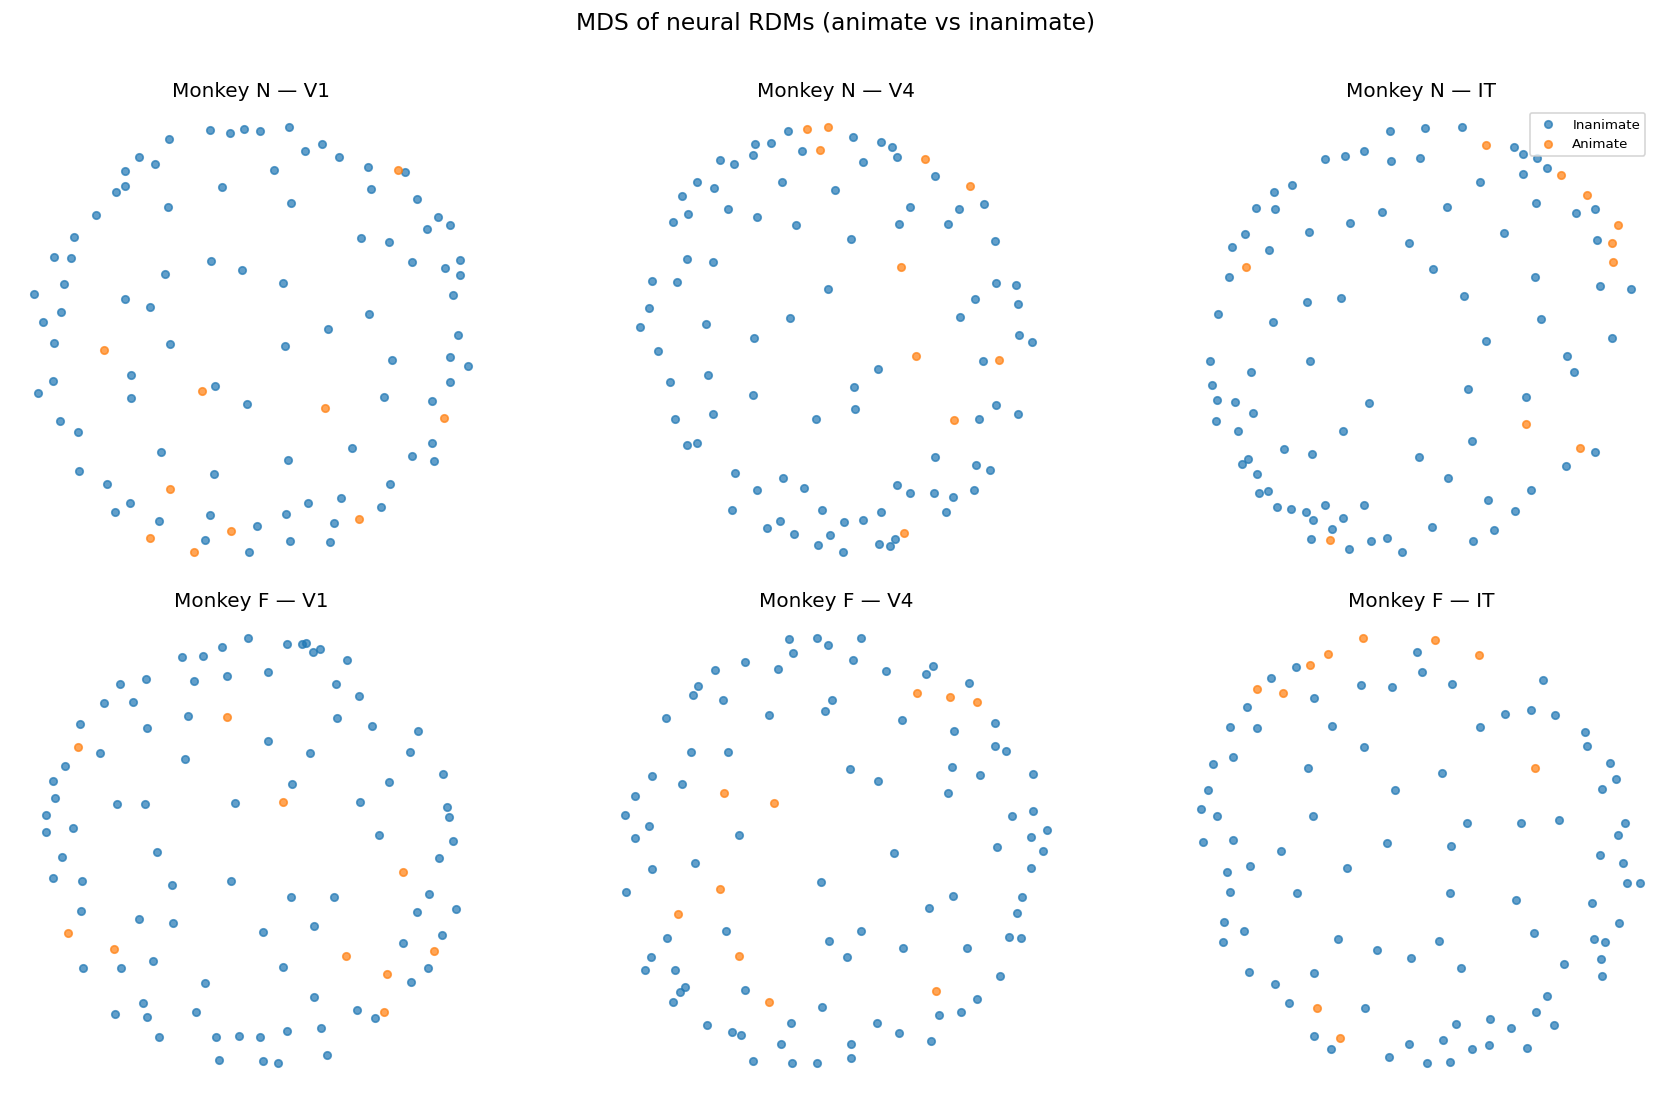

In [9]:
from sklearn import manifold

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
areas = ['V1', 'V4', 'IT']
colors = ['tab:blue', 'tab:orange']
cat_names = ['Inanimate', 'Animate']

for row, (monkey, rdms, anim) in enumerate([('N', rdms_N, anim_N), ('F', rdms_F, anim_F)]):
    for col, area in enumerate(areas):
        ax = axes[row, col]
        
        # MDS on precomputed dissimilarity
        mds = manifold.MDS(n_components=2, dissimilarity='precomputed', max_iter=300, n_init=4, random_state=42)
        coords = mds.fit_transform(rdms[area])
        
        for c_val, c_name in enumerate(cat_names):
            mask = anim == c_val
            ax.scatter(coords[mask, 0], coords[mask, 1], c=colors[c_val], label=c_name, s=20, alpha=0.7)
        
        ax.set_title(f'Monkey {monkey} — {area}')
        ax.set_aspect('equal', adjustable='box')
        ax.axis('off')
        if row == 0 and col == 2:
            ax.legend(loc='upper right', fontsize=8)

plt.suptitle('MDS of neural RDMs (animate vs inanimate)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Category structure: within vs between category distances

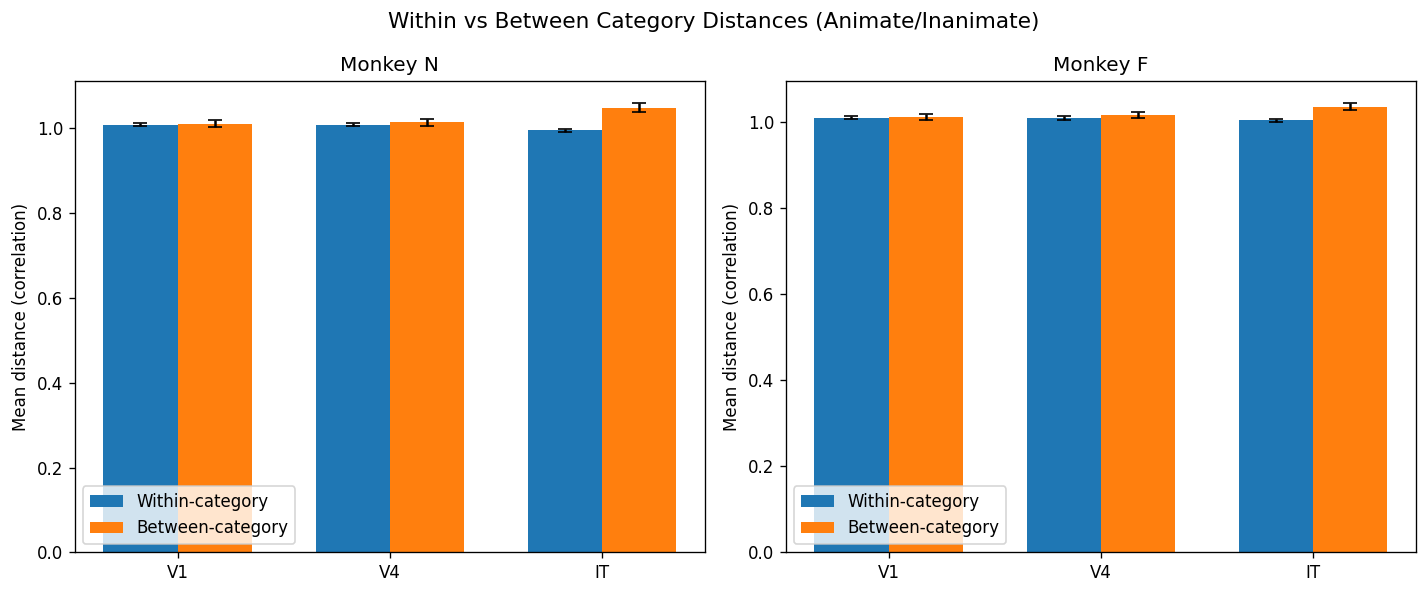

In [10]:
def within_between_distances(rdm, labels):
    """Compute mean within-category and between-category distances from an RDM."""
    n = len(labels)
    within = []
    between = []
    for i in range(n):
        for j in range(i+1, n):
            if labels[i] == labels[j]:
                within.append(rdm[i, j])
            else:
                between.append(rdm[i, j])
    return np.array(within), np.array(between)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (monkey, rdms, anim) in zip(axes, [('N', rdms_N, anim_N), ('F', rdms_F, anim_F)]):
    areas = ['V1', 'V4', 'IT']
    within_means = []
    between_means = []
    within_sems = []
    between_sems = []
    
    for area in areas:
        w, b = within_between_distances(rdms[area], anim)
        within_means.append(w.mean())
        between_means.append(b.mean())
        within_sems.append(w.std() / np.sqrt(len(w)))
        between_sems.append(b.std() / np.sqrt(len(b)))
    
    x = np.arange(len(areas))
    width = 0.35
    ax.bar(x - width/2, within_means, width, yerr=within_sems, label='Within-category', capsize=4)
    ax.bar(x + width/2, between_means, width, yerr=between_sems, label='Between-category', capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(areas)
    ax.set_ylabel('Mean distance (correlation)')
    ax.set_title(f'Monkey {monkey}')
    ax.legend()

plt.suptitle('Within vs Between Category Distances (Animate/Inanimate)', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# Category selectivity index: (between - within) / (between + within)
print("Category selectivity index per area:")
for monkey, rdms, anim in [('N', rdms_N, anim_N), ('F', rdms_F, anim_F)]:
    print(f"  Monkey {monkey}:")
    for area in ['V1', 'V4', 'IT']:
        w, b = within_between_distances(rdms[area], anim)
        csi = (b.mean() - w.mean()) / (b.mean() + w.mean())
        print(f"    {area}: CSI = {csi:.4f}  (within={w.mean():.4f}, between={b.mean():.4f})")

Category selectivity index per area:
  Monkey N:
    V1: CSI = 0.0013  (within=1.0089, between=1.0115)
    V4: CSI = 0.0031  (within=1.0086, between=1.0149)
    IT: CSI = 0.0262  (within=0.9953, between=1.0487)
  Monkey F:
    V1: CSI = 0.0004  (within=1.0091, between=1.0099)
    V4: CSI = 0.0033  (within=1.0083, between=1.0149)
    IT: CSI = 0.0156  (within=1.0027, between=1.0345)
